# Data Analysis & EDA
### German Traffic Sign Dataset (GTSRB)

## Step 1 — Install libraries

In [88]:
!pip install tensorflow tensorflow-datasets matplotlib seaborn scikit-learn scikit-image pillow --quiet

## Step 2 — Import libraries

In [89]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
from skimage.feature import hog
from skimage.color import rgb2gray
import tensorflow_datasets as tfds
import warnings
warnings.filterwarnings('ignore')
print('done')

done


## Step 3 — Download the dataset

In [90]:
import os
import cv2

def load_gtsrb(data_path, img_size=(32,32), test_size=0.2, random_state=42):
    images = []
    labels = []

    # Loop through class folders
    for label in sorted(os.listdir(data_path)):
        folder = os.path.join(data_path, label)
        # Skip if not a directory or not a number
        if not os.path.isdir(folder):
            continue
        if not label.isdigit():  # <-- skip non-numeric folders like "Meta"
            continue

        for img_name in os.listdir(folder):
            img_path = os.path.join(folder, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.resize(img, img_size)
            images.append(img)
            labels.append(int(label))

    X = np.array(images)
    y = np.array(labels)

    # Split into train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    train_ds = {"image": X_train, "label": y_train}
    test_ds  = {"image": X_test, "label": y_test}

    return train_ds, test_ds

In [91]:
# data_path = "/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Train"
data_path = r"C:\Users\moora\Downloads\archive (1)\Train"

train_ds, test_ds = load_gtsrb(data_path)

print("Train images:", train_ds["image"].shape)
print("Train labels:", train_ds["label"].shape)
print("Test images:", test_ds["image"].shape)
print("Test labels:", test_ds["label"].shape)

Train images: (31367, 32, 32, 3)
Train labels: (31367,)
Test images: (7842, 32, 32, 3)
Test labels: (7842,)


## Step 4 — Convert to numpy arrays
We resize every image to 32x32 so they are all the same size.

In [92]:
x_train, y_train = train_ds["image"], train_ds["label"]
x_test,  y_test  = test_ds["image"],  test_ds["label"]

print("train shape:", x_train.shape)
print("test shape: ", x_test.shape)

train shape: (31367, 32, 32, 3)
test shape:  (7842, 32, 32, 3)


## Step 5 — Class names

In [93]:
names = [
    'Speed 20', 'Speed 30', 'Speed 50', 'Speed 60', 'Speed 70',
    'Speed 80', 'End Speed 80', 'Speed 100', 'Speed 120', 'No Passing',
    'No Passing 3.5t', 'Right of Way', 'Priority Road', 'Yield', 'Stop',
    'No Vehicles', 'No Vehicles 3.5t', 'Do Not Enter', 'Caution', 'Curve Left',
    'Curve Right', 'Double Curve', 'Bumpy Road', 'Slippery', 'Road Narrows',
    'Road Work', 'Traffic Signal', 'Pedestrians', 'Children', 'Bicycles',
    'Ice Snow', 'Wild Animals', 'End Restrictions', 'Turn Right', 'Turn Left',
    'Ahead Only', 'Ahead or Right', 'Ahead or Left', 'Keep Right', 'Keep Left',
    'Roundabout', 'End No Passing', 'End No Passing 3.5t'
]
print('total classes:', len(names))

total classes: 43


## Step 6 — Basic info

In [94]:
print('training images :', x_train.shape[0])
print('test images     :', x_test.shape[0])
print('image size      :', x_small.shape[1], 'x', x_train.shape[2])
print('color channels  :', x_train.shape[3])
print('min pixel       :', x_train.min())
print('max pixel       :', x_train.max())

training images : 31367
test images     : 7842
image size      : 32 x 32
color channels  : 3
min pixel       : 0
max pixel       : 255


## Step 7 — Show one image from each class

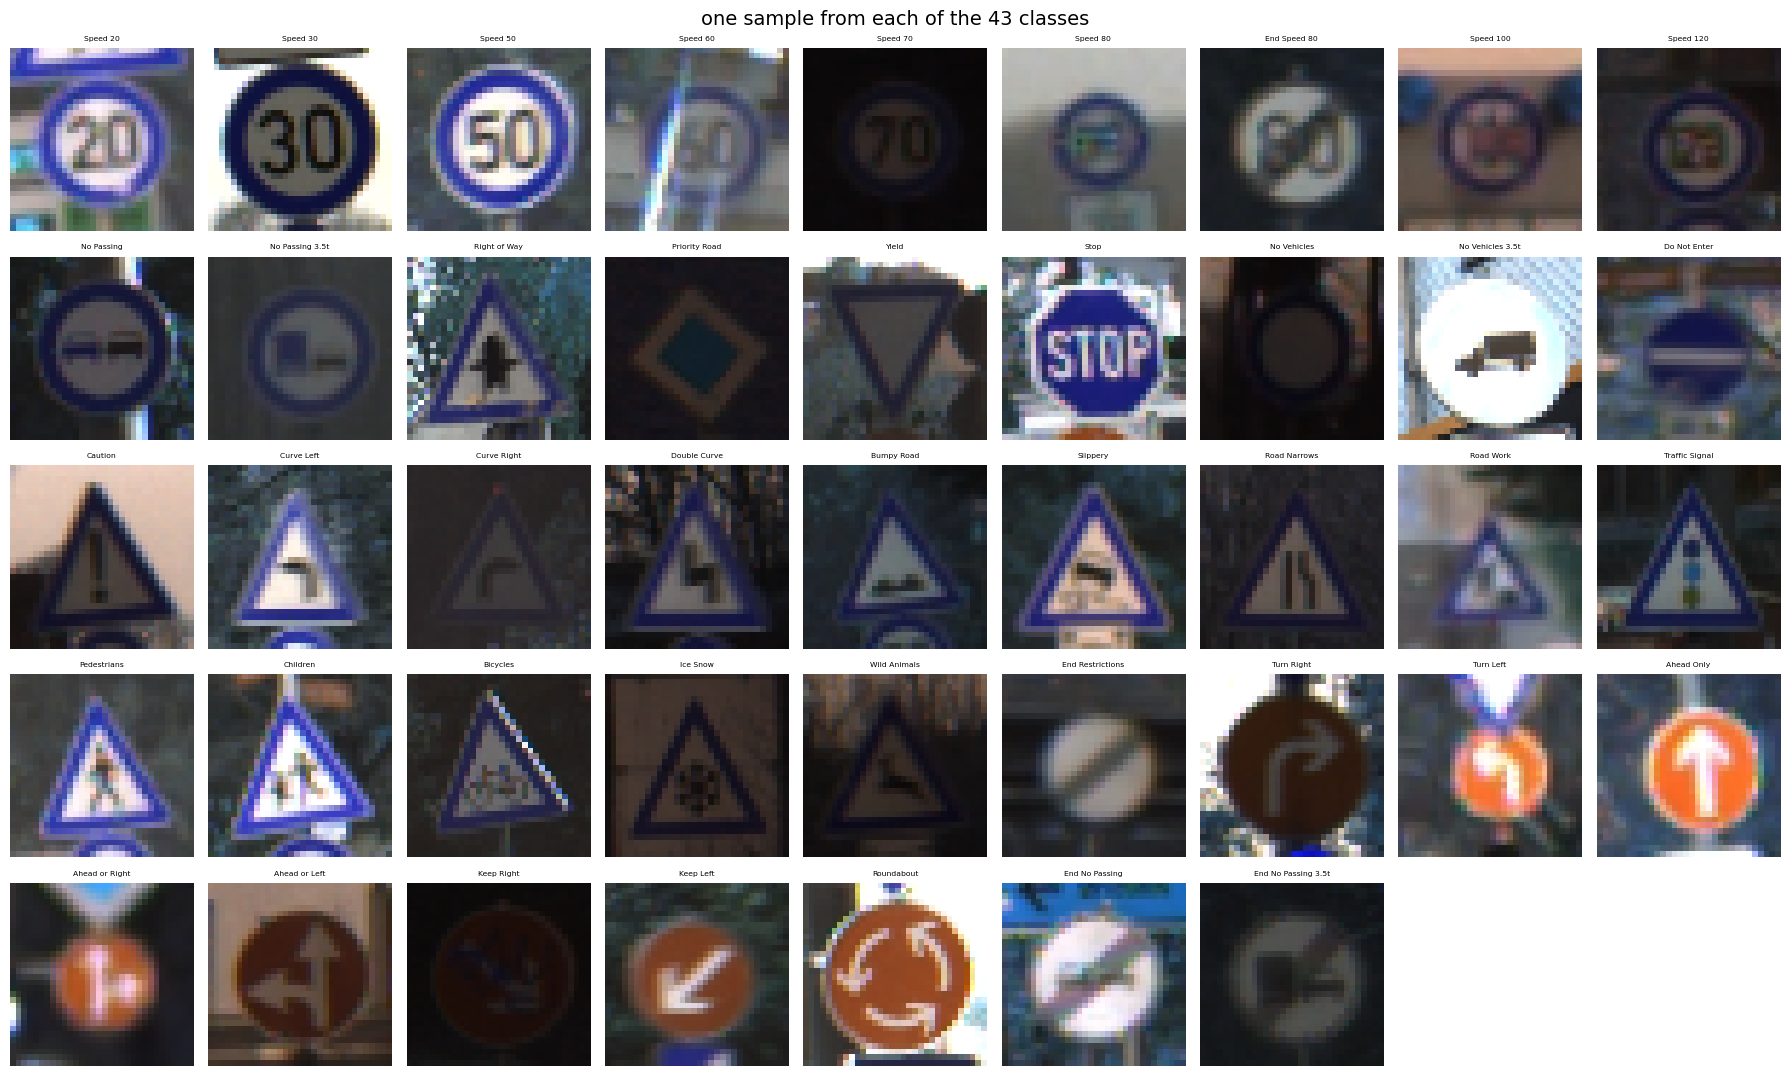

In [95]:
fig, axes = plt.subplots(5, 9, figsize=(18, 11))
fig.suptitle('one sample from each of the 43 classes', fontsize=14)

for i in range(43):
    ax = axes[i // 9][i % 9]
    idx = np.where(y_train == i)[0][0]
    ax.imshow(x_train[idx])
    ax.set_title(names[i], fontsize=5.5)
    ax.axis('off')

axes[4][7].axis('off')
axes[4][8].axis('off')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=100)
plt.show()

## Step 8 — Class balance

In [96]:
ids, counts = np.unique(y_train, return_counts=True)

df = pd.DataFrame({'class id': ids, 'name': names, 'count': counts})
print(df.to_string(index=False))
print()
print('most common  :', names[counts.argmax()], '-', counts.max(), 'images')
print('least common :', names[counts.argmin()], '-', counts.min(), 'images')
print('ratio        :', round(counts.max() / counts.min(), 1), 'x')

 class id                name  count
        0            Speed 20    168
        1            Speed 30   1776
        2            Speed 50   1800
        3            Speed 60   1128
        4            Speed 70   1584
        5            Speed 80   1488
        6        End Speed 80    336
        7           Speed 100   1152
        8           Speed 120   1128
        9          No Passing   1176
       10     No Passing 3.5t   1608
       11        Right of Way   1056
       12       Priority Road   1680
       13               Yield   1728
       14                Stop    624
       15         No Vehicles    504
       16    No Vehicles 3.5t    336
       17        Do Not Enter    888
       18             Caution    960
       19          Curve Left    168
       20         Curve Right    288
       21        Double Curve    264
       22          Bumpy Road    312
       23            Slippery    408
       24        Road Narrows    216
       25           Road Work   1200
 

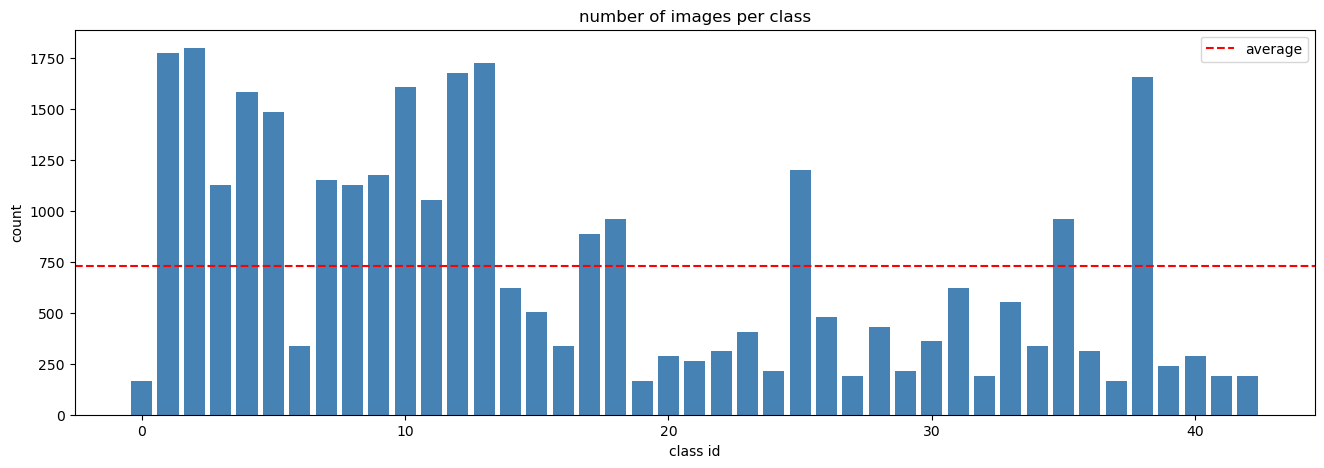

In [97]:
plt.figure(figsize=(16, 5))
plt.bar(ids, counts, color='steelblue')
plt.axhline(counts.mean(), color='red', linestyle='--', label='average')
plt.title('number of images per class')
plt.xlabel('class id')
plt.ylabel('count')
plt.legend()
plt.savefig('class_balance.png', dpi=100)
plt.show()

## Step 9 — Pixel statistics

In [98]:
print('average brightness :', round(x_train.mean(), 2))
print('std deviation      :', round(x_train.std(), 2))
print('red mean           :', round(x_train[:,:,:,0].mean(), 2))
print('green mean         :', round(x_train[:,:,:,1].mean(), 2))
print('blue mean          :', round(x_train[:,:,:,2].mean(), 2))

average brightness : 82.69
std deviation      : 69.06
red mean           : 81.89
green mean         : 79.53
blue mean          : 86.67


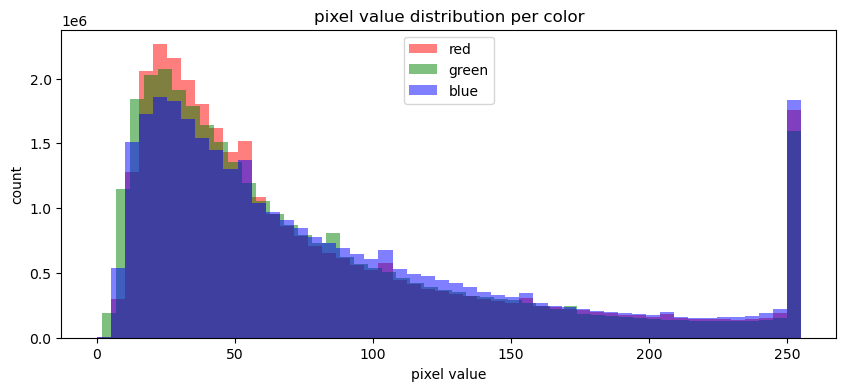

In [99]:
plt.figure(figsize=(10, 4))
plt.hist(x_train[:,:,:,0].flatten(), bins=50, color='red',   alpha=0.5, label='red')
plt.hist(x_train[:,:,:,1].flatten(), bins=50, color='green', alpha=0.5, label='green')
plt.hist(x_train[:,:,:,2].flatten(), bins=50, color='blue',  alpha=0.5, label='blue')
plt.title('pixel value distribution per color')
plt.xlabel('pixel value')
plt.ylabel('count')
plt.legend()
plt.savefig('pixel_distribution.png', dpi=100)
plt.show()

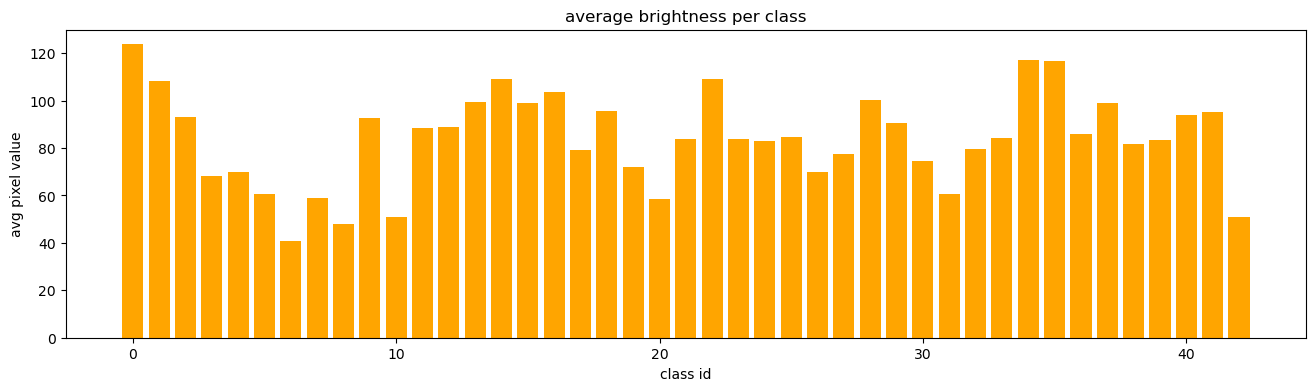

In [100]:
brightness = [x_train[y_train == i].mean() for i in range(43)]

plt.figure(figsize=(16, 4))
plt.bar(range(43), brightness, color='orange')
plt.title('average brightness per class')
plt.xlabel('class id')
plt.ylabel('avg pixel value')
plt.savefig('brightness_per_class.png', dpi=100)
plt.show()

## Step 10 — Data health check

In [101]:
print('nan values?          :', np.isnan(x_train.astype(float)).any())
print('all black images     :', (x_train.mean(axis=(1,2,3)) == 0).sum())
print('all white images     :', (x_train.mean(axis=(1,2,3)) == 255).sum())
print('min label value      :', y_train.min())
print('max label value      :', y_train.max())
print('unique classes found :', len(np.unique(y_train)))
print('pixel type           :', x_train.dtype)
print()
print('data is clean!')

nan values?          : False
all black images     : 0
all white images     : 0
min label value      : 0
max label value      : 42
unique classes found : 43
pixel type           : uint8

data is clean!


## Step 11 — Mean image per class

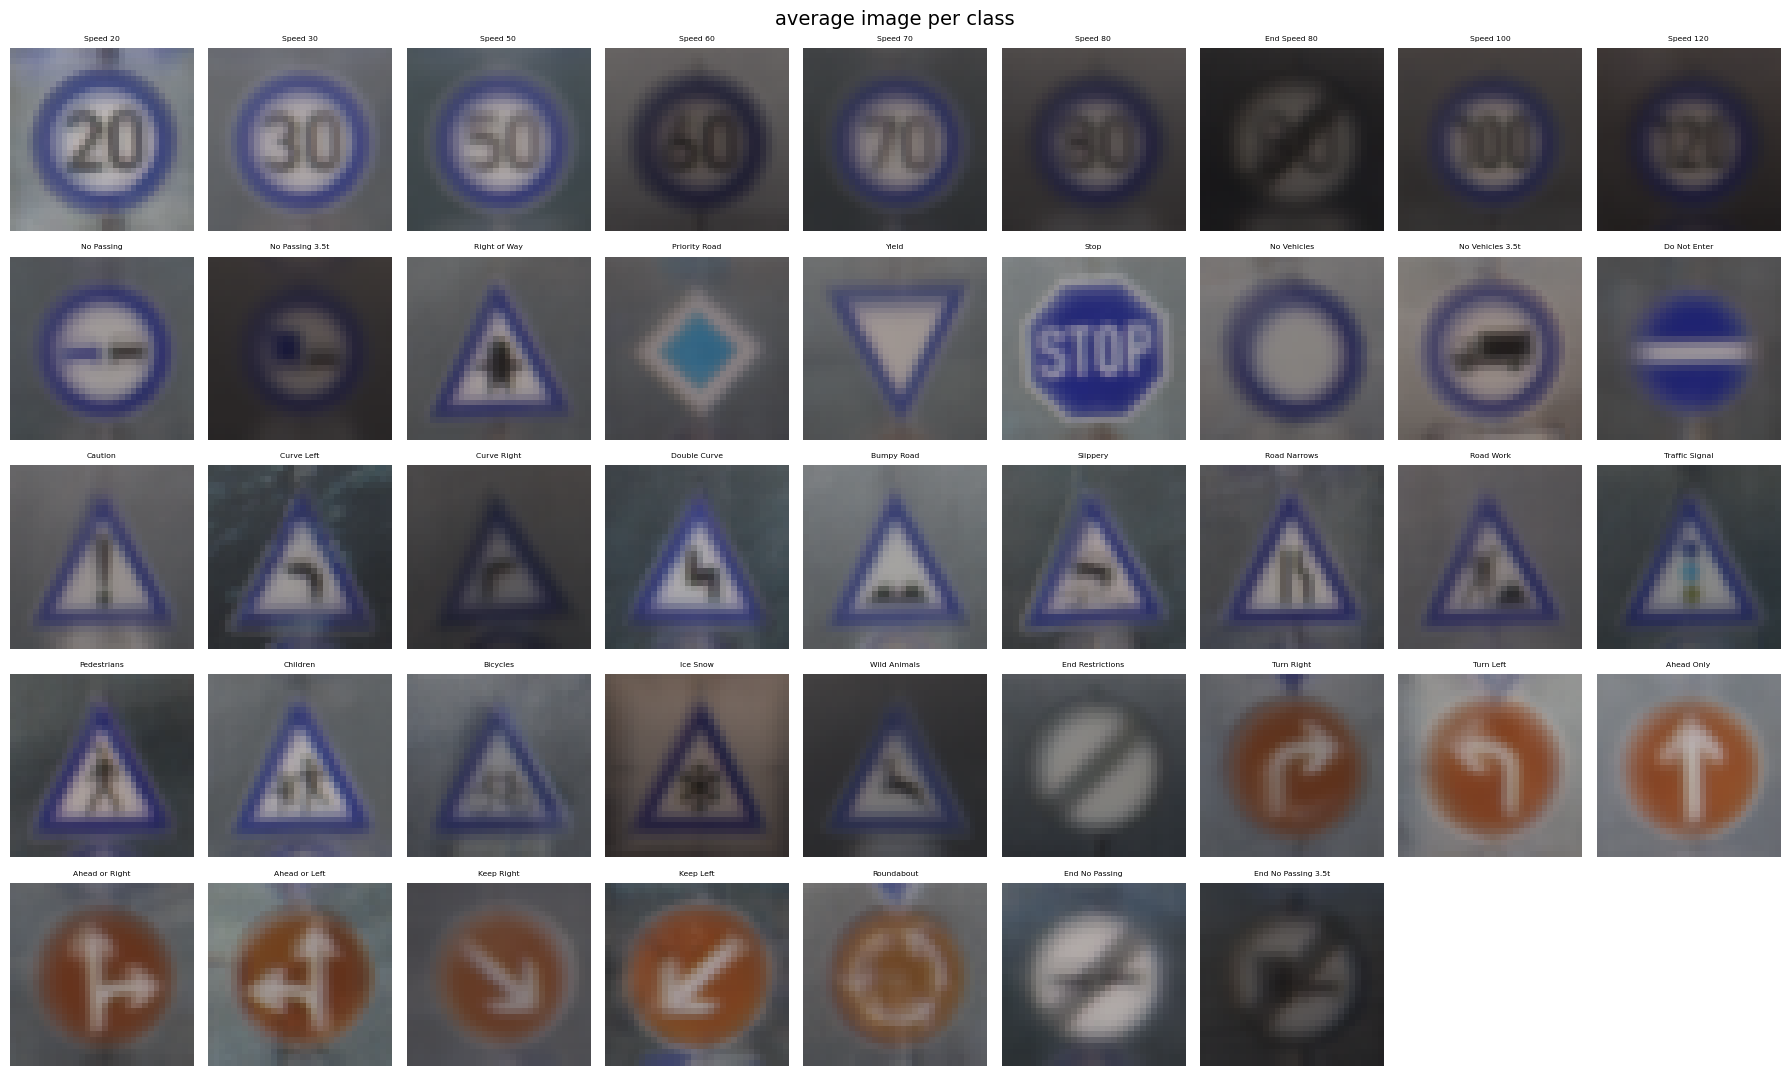

In [102]:
fig, axes = plt.subplots(5, 9, figsize=(18, 11))
fig.suptitle('average image per class', fontsize=14)

for i in range(43):
    ax = axes[i // 9][i % 9]
    mean_img = x_train[y_train == i].mean(axis=0).astype(np.uint8)
    ax.imshow(mean_img)
    ax.set_title(names[i], fontsize=5.5)
    ax.axis('off')

axes[4][7].axis('off')
axes[4][8].axis('off')
plt.tight_layout()
plt.savefig('mean_images.png', dpi=100)
plt.show()

In [103]:
import sys

# Add the helper folder from your dataset to Python path
sys.path.append("/kaggle/input/datasets/baselhelayel/helper")

## Step 12 — Feature extraction (feature_extraction.py)

In [104]:
from feature_extraction import FeatureExtractor
print('imported')

imported


In [105]:
sample_idx = []
for i in range(43):
    idx = np.where(y_train == i)[0][:55]
    sample_idx.extend(idx)

x_small = x_train[sample_idx]
y_small = y_train[sample_idx]

fe = FeatureExtractor(resize=(32, 32))
x_features = fe.extract_from_list(list(x_small))

print('features shape:', x_features.shape)

features shape: (2365, 420)


## Step 13 — HOG visualization

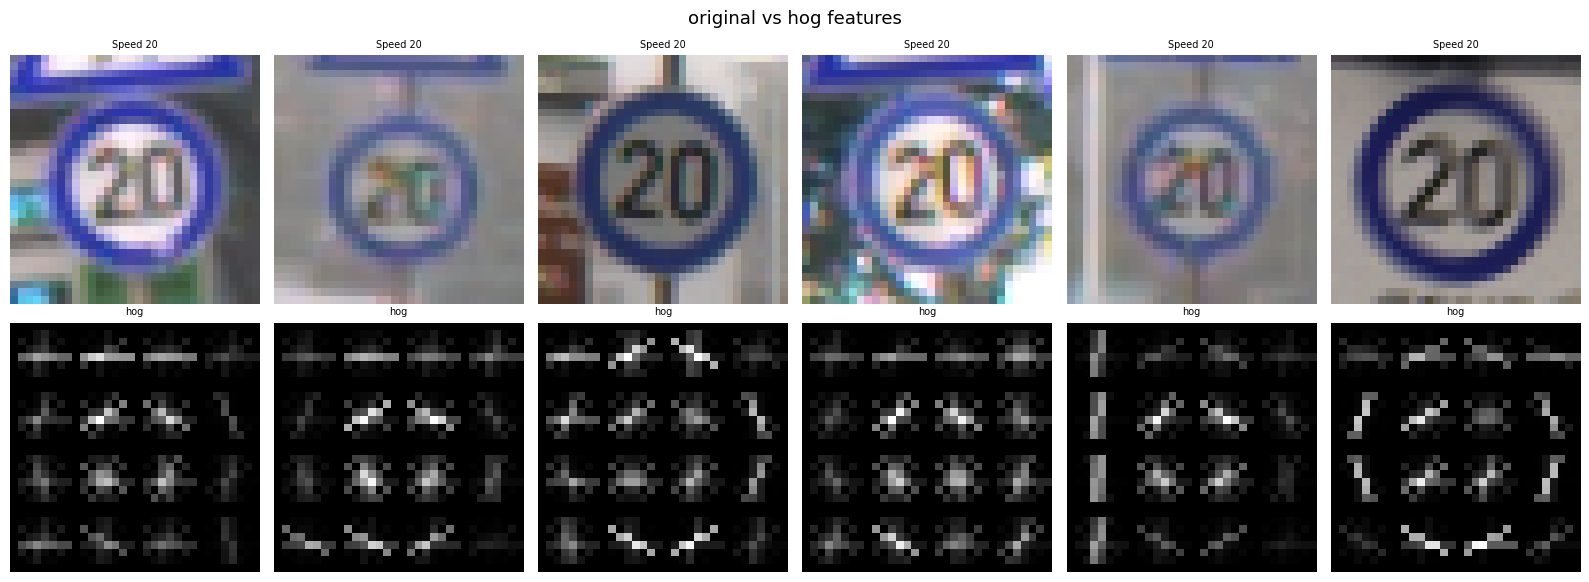

In [106]:
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
fig.suptitle('original vs hog features', fontsize=13)

for i in range(6):
    img = x_small[i]
    gray = rgb2gray(img)
    _, hog_img = hog(gray, visualize=True)

    axes[0][i].imshow(img)
    axes[0][i].set_title(names[y_small[i]], fontsize=7)
    axes[0][i].axis('off')

    axes[1][i].imshow(hog_img, cmap='gray')
    axes[1][i].set_title('hog', fontsize=7)
    axes[1][i].axis('off')

plt.tight_layout()
plt.savefig('hog_features.png', dpi=100)
plt.show()

## Step 14 — Baseline models + Feature Extraction

In [107]:
from baselines import BaselineModels
print('imported')

imported


In [108]:
x_tr, x_te, y_tr, y_te = train_test_split(x_features, y_small, test_size=0.25, random_state=42)

model = BaselineModels(knn_k=5, use_scaler=True, use_pca=False)
model.fit(x_tr, y_tr)

knn_res = model.evaluate(x_te, y_te, model='knn')
nb_res  = model.evaluate(x_te, y_te, model='nb')

print('knn results:')
for k, v in knn_res.items():
    if k != 'confusion_matrix':
        print('     ', k, ':', round(v, 3))

print()
print('naive bayes results:')
for k, v in nb_res.items():
    if k != 'confusion_matrix':
        print('     ', k, ':', round(v, 3))

knn results:
      accuracy : 0.633
      precision : 0.698
      recall : 0.657
      f1 : 0.658

naive bayes results:
      accuracy : 0.598
      precision : 0.637
      recall : 0.612
      f1 : 0.609


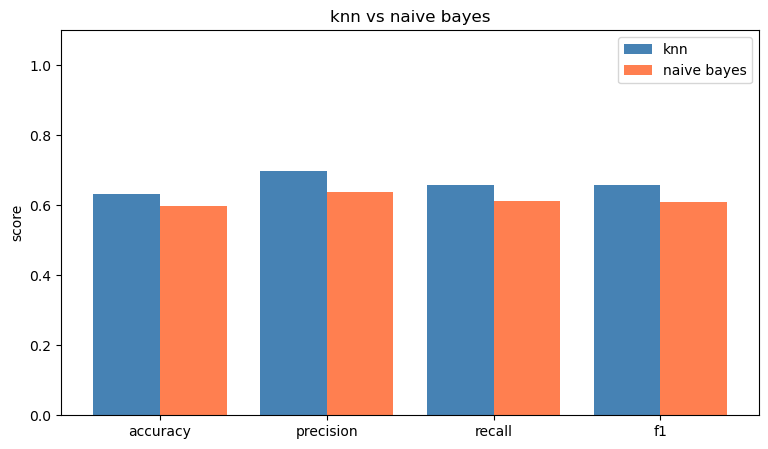

In [109]:
metrics = ['accuracy', 'precision', 'recall', 'f1']
knn_vals = [knn_res[m] for m in metrics]
nb_vals  = [nb_res[m]  for m in metrics]

x = np.arange(len(metrics))
plt.figure(figsize=(9, 5))
plt.bar(x - 0.2, knn_vals, 0.4, label='knn',         color='steelblue')
plt.bar(x + 0.2, nb_vals,  0.4, label='naive bayes', color='coral')
plt.xticks(x, metrics)
plt.ylim(0, 1.1)
plt.ylabel('score')
plt.title('knn vs naive bayes')
plt.legend()
plt.savefig('model_comparison.png', dpi=100)
plt.show()

#### Confusion Matrix for Baseline models + Feature Extraction

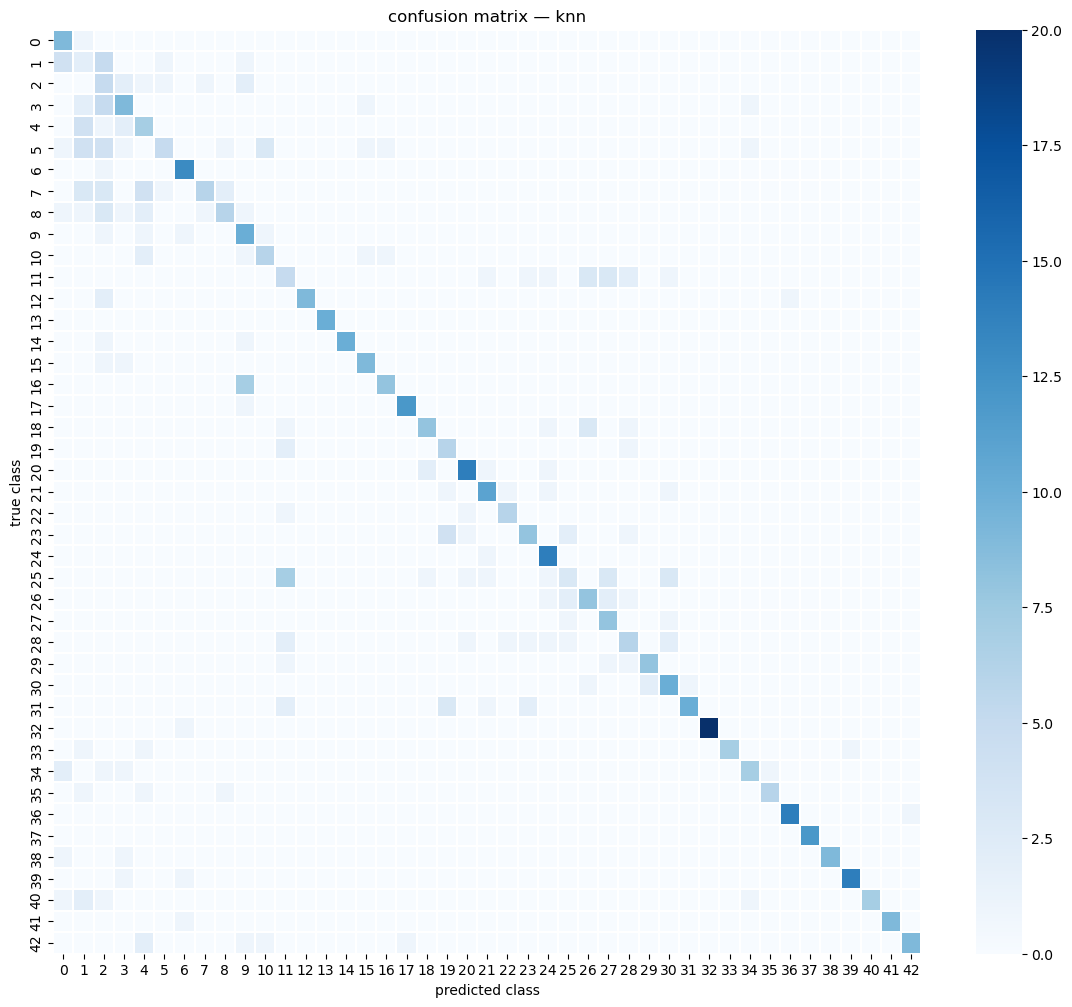

In [110]:
y_pred = model.predict(x_te, model='knn')
cm = confusion_matrix(y_te, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, cmap='Blues', linewidths=0.3)
plt.title('confusion matrix — knn')
plt.ylabel('true class')
plt.xlabel('predicted class')
plt.savefig('confusion_matrix.png', dpi=100)
plt.show()

## Step 15 — PCA

In [111]:
scaler = StandardScaler()

x_tr, x_te, y_tr, y_te = train_test_split(x_small, y_small, test_size=0.25, random_state=42)

x_train_2d = np.reshape(x_tr, (x_tr.shape[0], x_tr.shape[1]*x_tr.shape[2]*x_tr.shape[3])) 
x_test_2d  = np.reshape(x_te, (x_te.shape[0], x_te.shape[1]*x_te.shape[2]*x_te.shape[3]))

scaler.fit(x_train_2d)
x_scaled_train = scaler.transform(x_train_2d)
x_scaled_test =  scaler.transform(x_test_2d)

pca = PCA()
pca.fit(x_scaled_train)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

#### Graphing the cumulative variance and choosing the optimal number of components

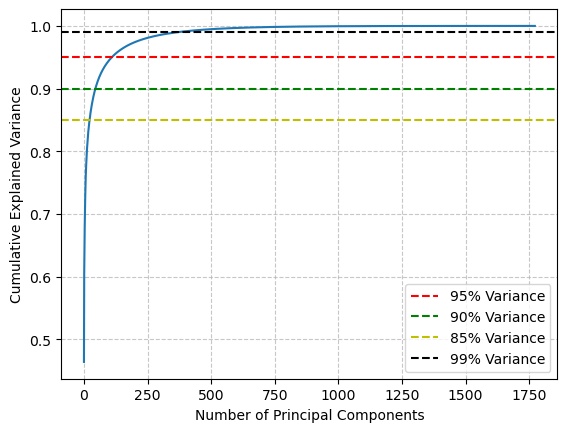

Number of components for 85% variance: 24
Number of components for 90% variance: 46
Number of components for 95% variance: 111
Number of components for 99% variance: 369


In [112]:
plt.plot(cumulative_variance)
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True, linestyle='--', alpha=0.7)

plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
plt.axhline(y=0.90, color='g', linestyle='--', label='90% Variance')
plt.axhline(y=0.85, color='y', linestyle='--', label='85% Variance')
plt.axhline(y=0.99, color='black', linestyle='--', label='99% Variance')
plt.legend(loc='best')

plt.show()

# Print the exact number of components needed for [85, 90, 95]% variances
components = []

components.append(np.argmax(cumulative_variance >= 0.85) + 1)
components.append(np.argmax(cumulative_variance >= 0.90) + 1)
components.append(np.argmax(cumulative_variance >= 0.95) + 1)
components.append(np.argmax(cumulative_variance >= 0.99) + 1)

print(f"Number of components for 85% variance: {components[0]}")
print(f"Number of components for 90% variance: {components[1]}")
print(f"Number of components for 95% variance: {components[2]}")
print(f"Number of components for 99% variance: {components[3]}")

#### Using the Feature Extracted data

In [113]:
scaler = StandardScaler()

x_tr, x_te, y_tr, y_te = train_test_split(x_features, y_small, test_size=0.25, random_state=42)

scaler.fit(x_tr)
x_scaled_train = scaler.transform(x_tr)
x_scaled_test =  scaler.transform(x_te)

pca = PCA()
pca.fit(x_scaled_train)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

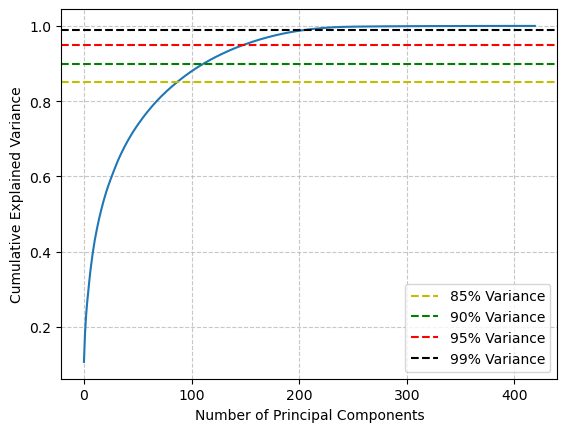

Number of components for 85% variance: 88
Number of components for 90% variance: 113
Number of components for 95% variance: 150
Number of components for 99% variance: 208


In [114]:
plt.plot(cumulative_variance)
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True, linestyle='--', alpha=0.7)

plt.axhline(y=0.85, color='y', linestyle='--', label='85% Variance')
plt.axhline(y=0.90, color='g', linestyle='--', label='90% Variance')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
plt.axhline(y=0.99, color='black', linestyle='--', label='99% Variance')
plt.legend(loc='best')

plt.show()

# Print the exact number of components needed for [85, 90, 95, 99]% variances
components = []

components.append(np.argmax(cumulative_variance >= 0.85) + 1)
components.append(np.argmax(cumulative_variance >= 0.90) + 1)
components.append(np.argmax(cumulative_variance >= 0.95) + 1)
components.append(np.argmax(cumulative_variance >= 0.99) + 1)

print(f"Number of components for 85% variance: {components[0]}")
print(f"Number of components for 90% variance: {components[1]}")
print(f"Number of components for 95% variance: {components[2]}")
print(f"Number of components for 99% variance: {components[3]}")

#### Baseline + Feature selection + PCA (with different Number of components)

In [115]:
from baselines import BaselineModels
import time

# we will us the (PCA) data
x_tr, x_te, y_tr, y_te

exe_time = []
knn_results = []
NB_results = []

for comp in components: # [0.85, 0.90, 0.95, 0.99] %
    start = time.time()
    
    print(f'creating model for number of fetures : {comp}')
    model = BaselineModels(knn_k=5, use_scaler=True, use_pca=True, pca_components=comp)
    print('fitting both models: ')
    model.fit(x_tr, y_tr)
    
    print('evaluating Knn: ')
    knn = model.evaluate(x_te, y_te, model='knn')
    print('evaluating NB: ')
    nb = model.evaluate(x_te, y_te, model='nb')
    
    end = time.time()
    print('---------------------------------------------------------------------')

    knn_results.append(knn)
    NB_results.append(nb)

    exe_time.append((end - start))

creating model for number of fetures : 88
fitting both models: 
evaluating Knn: 
evaluating NB: 
---------------------------------------------------------------------
creating model for number of fetures : 113
fitting both models: 
evaluating Knn: 
evaluating NB: 
---------------------------------------------------------------------
creating model for number of fetures : 150
fitting both models: 
evaluating Knn: 
evaluating NB: 
---------------------------------------------------------------------
creating model for number of fetures : 208
fitting both models: 
evaluating Knn: 
evaluating NB: 
---------------------------------------------------------------------


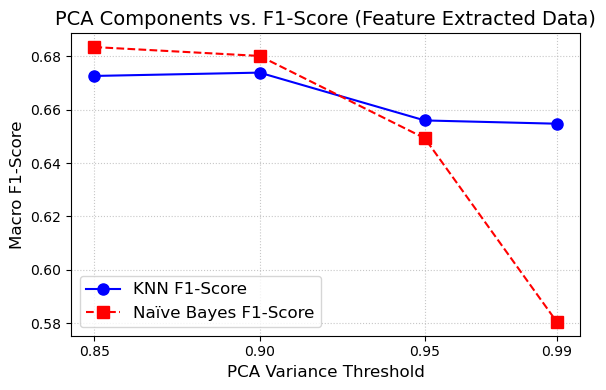

In [116]:
# The data from your experiment
components = [0.85, 0.9, 0.95, 0.99]
knn_f1 = [x['f1'] for x in knn_results]
nb_f1 =  [x['f1']  for x in NB_results]

plt.figure(figsize=(6, 4))

# Plot KNN
plt.plot(components, knn_f1, marker='o', linestyle='-', color='b', 
         label='KNN F1-Score', markersize=8)

# Plot Naïve Bayes
plt.plot(components, nb_f1, marker='s', linestyle='--', color='r', 
         label='Naïve Bayes F1-Score', markersize=8)

# Formatting
plt.title('PCA Components vs. F1-Score (Feature Extracted Data)', fontsize=14)
plt.xlabel('PCA Variance Threshold', fontsize=12)
plt.ylabel('Macro F1-Score', fontsize=12)
plt.xticks(components)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=12)

# Save and show
plt.tight_layout()
plt.savefig('pca_comparison.png', dpi=300)
plt.show()

looking at the graph the most balanced is at 0.95, but much time did each take? 

the time shown will be the total sum of (fitting the data + evaluating for both KNN and NB models)

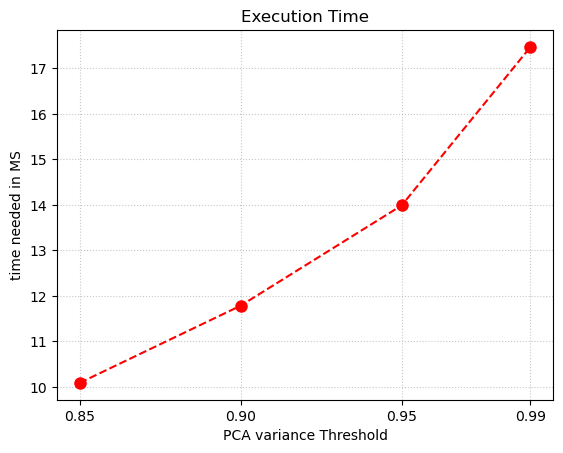

In [117]:
components = [0.85, 0.9, 0.95, 0.99]
exe_time = [x*100 for x in exe_time]

plt.plot(components, exe_time, color='r', marker='o', markersize=8, linestyle='--')
plt.title('Execution Time')
plt.xlabel('PCA variance Threshold')
plt.ylabel('time needed in MS')
plt.xticks(components)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

the time for (0.85, 0.90 and 0.95) are relatively similar with 0.99 being extremely larger, so the pick is going to be 0.95 

In [118]:
print('NB :')
print(f'    F1       : {NB_results[2]['f1']:0.4f}')
print(f'    Accuracy : {NB_results[2]['accuracy']:0.4f}')
print(f'    Precision: {NB_results[2]['precision']:0.4f}')
print(f'    Recall   : {NB_results[2]['recall']:0.4f}')

print('KNN :')
print(f'    F1       : {knn_results[2]['f1']:0.4f}')
print(f'    Accuracy : {knn_results[2]['accuracy']:0.4f}')
print(f'    Precision: {knn_results[2]['precision']:0.4f}')
print(f'    Recall   : {knn_results[2]['recall']:0.4f}')

NB :
    F1       : 0.6493
    Accuracy : 0.6419
    Precision: 0.6847
    Recall   : 0.6571
KNN :
    F1       : 0.6560
    Accuracy : 0.6334
    Precision: 0.6946
    Recall   : 0.6560


#### Confusion Matrix for Baseline + Feature selection + (PCA at 0.95)

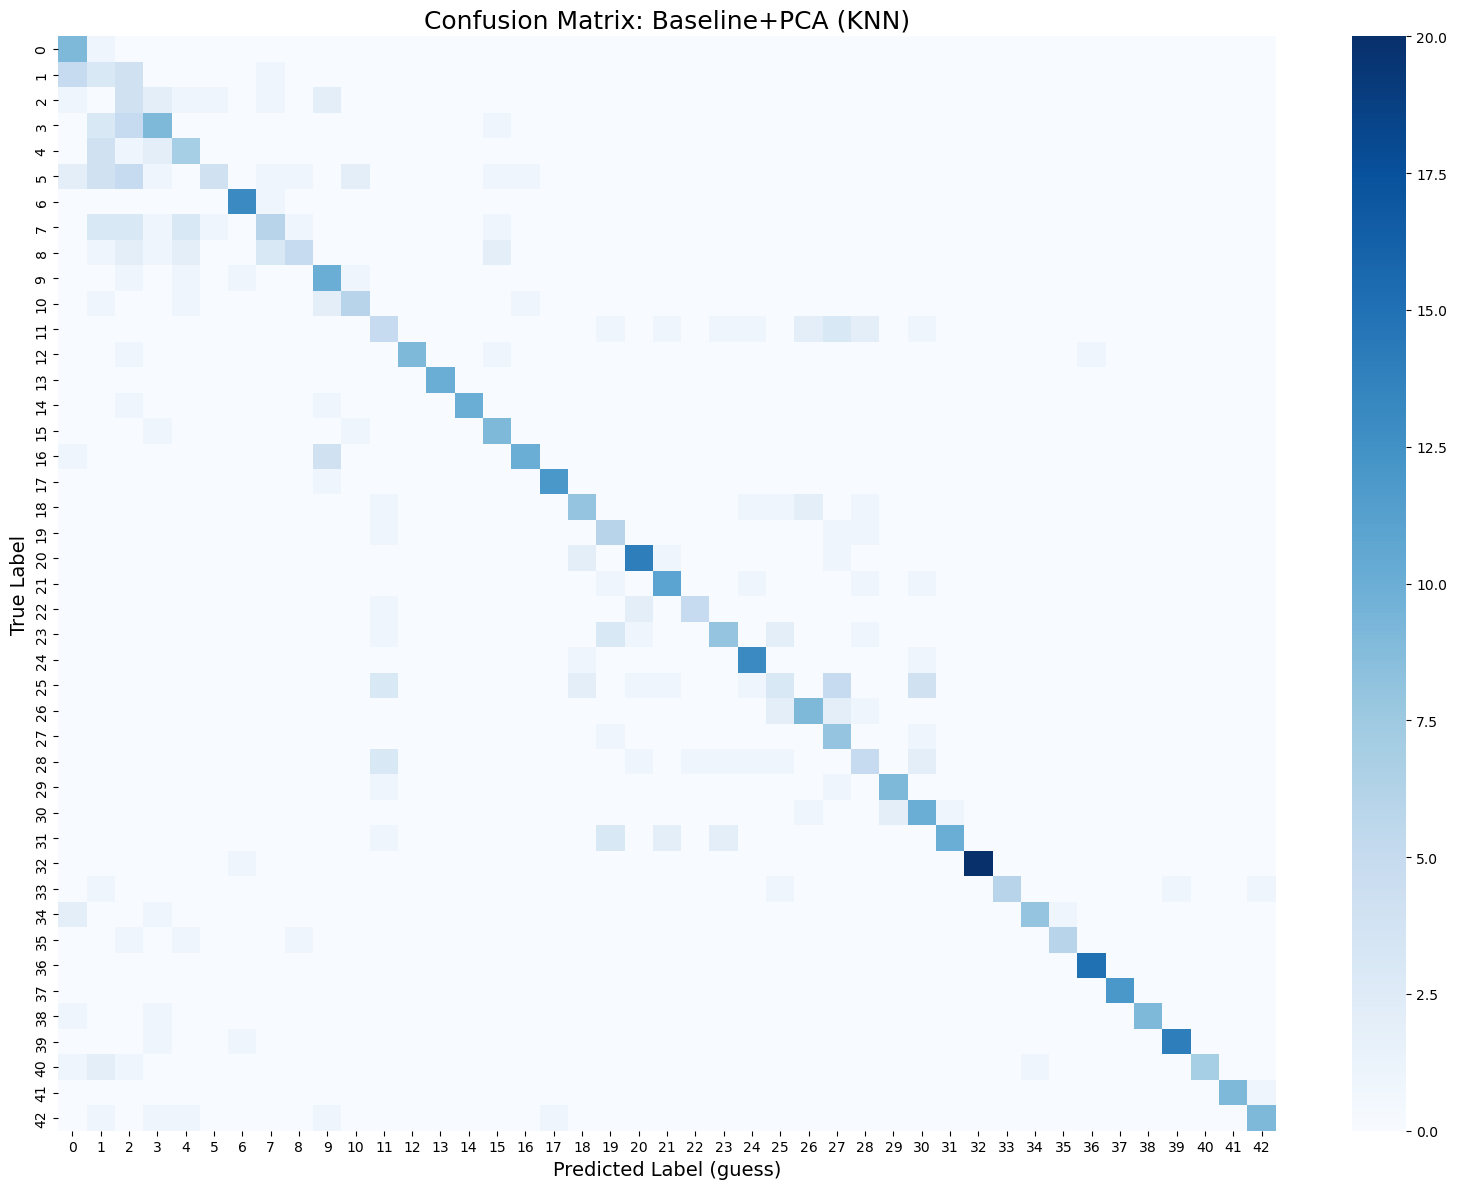

In [119]:
cm = knn_results[2]['confusion_matrix']

plt.figure(figsize=(16, 12))
sns.heatmap(cm, annot=False, cmap='Blues', cbar=True)

plt.title('Confusion Matrix: Baseline+PCA (KNN)', fontsize=18)
plt.xlabel('Predicted Label (guess)', fontsize=14)
plt.ylabel('True Label', fontsize=14)

plt.tight_layout()
plt.show()

## Step 16 — Full pipeline

In [120]:
from pipeline_example import run_pipeline
print('imported')

imported


In [121]:
run_pipeline(images=list(x_small), labels=list(y_small))

KNN metrics:
  accuracy: 0.7297297297297297
  precision: 0.7919208273706438
  recall: 0.7474507396748018
  f1: 0.7511881568699815
  confusion_matrix: [[ 9  0  0 ...  0  0  0]
 [ 1  6  2 ...  0  0  0]
 [ 0  0  7 ...  0  0  0]
 ...
 [ 0  0  1 ...  8  0  0]
 [ 0  0  0 ...  0 10  0]
 [ 0  0  0 ...  0  0 14]]

Naive Bayes metrics:
  accuracy: 0.7483108108108109
  precision: 0.8530996215716015
  recall: 0.7705251426919655
  f1: 0.7808820978319021
  confusion_matrix: [[ 7  1  1 ...  1  0  0]
 [ 0  4  1 ...  5  0  0]
 [ 0  2  9 ...  0  0  0]
 ...
 [ 0  0  0 ... 11  0  0]
 [ 0  0  0 ...  1  9  0]
 [ 0  0  0 ...  6  0  8]]
